# STEP1: 读取C101.txt

In [1]:
def parse_solomon(filepath):
    """
    解析 Solomon VRPTW benchmark 格式的文件（C101.txt）
    
    返回：
        num_vehicles: 车辆数量
        capacity: 每辆车的容量
        depot: 仓库信息（字典）
        customers: 客户列表（字典列表）
    """
    
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    # --- 找车辆信息 ---
    # 逐行找 "NUMBER" 这个关键词，下一行就是数字
    for i, line in enumerate(lines):
        if 'NUMBER' in line:
            parts = lines[i + 1].split()
            num_vehicles = int(parts[0])
            capacity = int(parts[1])
            break
    
    # --- 找客户数据 ---
    # 找到 "CUST NO." 这行，之后的非空行都是数据
    customer_start = None
    for i, line in enumerate(lines):
        if 'CUST' in line and 'NO' in line:
            customer_start = i + 1  # 数据从下一行开始
            break
    
    depot = None
    customers = []
    
    for line in lines[customer_start:]:   #bug1: lines[], 不是单数line
        parts = line.split()
        if len(parts) == 0:   # 跳过空行  #bug2: len(line)不对 # ❌ 判断的是字符串长度，空行也有 \n，长度不是0
            continue
        
        # 把7列数字读进来
        node = {
            'id':           int(parts[0]),
            'x':            float(parts[1]),
            'y':            float(parts[2]),
            'demand':       float(parts[3]),
            'ready_time':   float(parts[4]),
            'due_date':     float(parts[5]),
            'service_time': float(parts[6]),
        }
        
        if node['id'] == 0:
            depot = node      # 第0个是仓库
        else:
            customers.append(node)
    
    return num_vehicles, capacity, depot, customers


# ---- 运行 ----
num_vehicles, capacity, depot, customers = parse_solomon('c101.txt')

print(f"车辆数: {num_vehicles}, 容量: {capacity}")
print(f"仓库: {depot}")
print(f"客户数: {len(customers)}")
print(f"第一个客户: {customers[0]}")

车辆数: 25, 容量: 200
仓库: {'id': 0, 'x': 40.0, 'y': 50.0, 'demand': 0.0, 'ready_time': 0.0, 'due_date': 1236.0, 'service_time': 0.0}
客户数: 100
第一个客户: {'id': 1, 'x': 45.0, 'y': 68.0, 'demand': 10.0, 'ready_time': 912.0, 'due_date': 967.0, 'service_time': 90.0}


# STEP2: 建模


1. 距离矩阵

In [2]:
import math

def compute_distance_matrix(depot, customers):
    # 把depot和customers合并成一个列表，depot在第0位
    nodes = [depot] + customers  # depot是字典，需要先变成列表才能和customer这个列表相加
    n = len(nodes)  # 101
     
    # 要先规定出全为0的矩阵，这里是101x101矩阵
    dist_matrix = [[0] * n for _ in range(n)]
    
    for i in range(n):
        for j in range(n):
            if i != j:
                dx = nodes[i]['x'] - nodes[j]['x']
                dy = nodes[i]['y'] - nodes[j]['y']
                dist_matrix[i][j] = int(math.sqrt(dx**2 + dy**2))
    
    return dist_matrix

2. 创建 OR-Tools 模型

In [3]:
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
import math

def create_model(num_vehicles, capacity, depot, customers, dist_matrix):
    
    # 1. 创建模型管理器
    manager = pywrapcp.RoutingIndexManager(
        len(dist_matrix),   # 节点总数 101
        num_vehicles,       # 车辆数 25
        0                   # depot 的编号（第0个节点）
    )
    
    # 2. 创建路径模型
    routing = pywrapcp.RoutingModel(manager)
    
    # 3. 告诉模型怎么计算两点之间的距离
    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return dist_matrix[from_node][to_node]
    
    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)
    
    return manager, routing

3. 添加容量约束

In [4]:
def add_capacity_constraint(routing, manager, customers, capacity):
    
    # 1. 告诉模型每个节点的需求量是多少
    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        if from_node == 0:
            return 0  # depot 需求为0
        return int(customers[from_node - 1]['demand'])  # 注意 -1   ####！！！要用int
    
    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    
    # 2. 添加容量约束
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,                          # 没有slack
        [capacity] * num_vehicles,  # 每辆车的容量上限
        True,                       # 从0开始累积
        'Capacity'                  # 这个约束的名字
    )

4. 添加时间窗约束

In [5]:
def add_time_window_constraint(routing, manager, depot, customers, dist_matrix):
    
    # 1. 告诉模型每段路程花多少时间
    def time_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        
        # 行驶时间 + 在当前节点的服务时间
        if from_node == 0:
            service_time = 0
        else:
            service_time = customers[from_node - 1]['service_time']
        
        return dist_matrix[from_node][to_node] + service_time
    
    time_callback_index = routing.RegisterTransitCallback(time_callback)
    
    # 2. 创建时间维度
    routing.AddDimension(
        time_callback_index,
        1236,       # slack：允许等待的最大时间
        1236,       # 最大时间上限（depot的due_date）
        False,      # 不从0开始（允许等待）
        'Time'
    )
    
    time_dimension = routing.GetDimensionOrDie('Time')
    
    # 3. 给每个节点加时间窗
    nodes = [depot] + customers
    for i, node in enumerate(nodes):
        index = manager.NodeToIndex(i)
        time_dimension.CumulVar(index).SetRange(
            int(node['ready_time']),
            int(node['due_date'])
        )

5. 求解

In [6]:
def solve(routing, manager, customers):
    
    # 1. 设置搜索参数
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_parameters.time_limit.seconds = 30  # 最多搜索30秒
    
    # 2. 求解
    solution = routing.SolveWithParameters(search_parameters)
    
    # 3. 输出结果
    if solution:
        total_distance = 0
        routes = [] 
        for vehicle_id in range(num_vehicles):
            index = routing.Start(vehicle_id)
            route = []
            route_distance = 0
            
            while not routing.IsEnd(index):
                node = manager.IndexToNode(index)
                route.append(node)
                next_index = solution.Value(routing.NextVar(index))
                route_distance += dist_matrix[node][manager.IndexToNode(next_index)]
                index = next_index
            
            route.append(0)  # 回到depot
            
            if len(route) > 2:  # 排除空路线
                routes.append(route)
                end_time = solution.Value(
                    routing.GetDimensionOrDie('Time').CumulVar(routing.End(vehicle_id))
                )
                print(f"车辆 {vehicle_id}: {route}, 距离: {route_distance:.2f}, 结束时间: {end_time}")
                total_distance += route_distance
                
        print(f"\n总距离: {total_distance:.2f}")
        return routes
    else:
        print("没有找到解")

In [7]:
num_vehicles, capacity, depot, customers = parse_solomon('c101.txt')
dist_matrix = compute_distance_matrix(depot, customers)
manager, routing = create_model(num_vehicles, capacity, depot, customers, dist_matrix)  # important

add_capacity_constraint(routing, manager, customers, capacity)
add_time_window_constraint(routing, manager, depot, customers, dist_matrix)
solve(routing, manager, customers)

车辆 11: [0, 5, 3, 0], 距离: 32.00, 结束时间: 65
车辆 12: [0, 7, 0], 距离: 32.00, 结束时间: 170
车辆 13: [0, 13, 8, 0], 距离: 65.00, 结束时间: 255
车辆 14: [0, 24, 20, 17, 10, 0], 距离: 82.00, 结束时间: 357
车辆 15: [0, 43, 33, 32, 31, 25, 18, 15, 0], 距离: 138.00, 结束时间: 384
车辆 16: [0, 57, 55, 42, 41, 35, 27, 19, 16, 11, 0], 距离: 188.00, 结束时间: 475
车辆 17: [0, 67, 65, 63, 54, 53, 40, 37, 29, 14, 9, 0], 距离: 207.00, 结束时间: 567
车辆 18: [0, 81, 78, 76, 71, 62, 56, 44, 38, 30, 28, 0], 距离: 237.00, 结束时间: 546
车辆 19: [0, 83, 82, 74, 70, 58, 46, 45, 39, 0], 距离: 271.00, 结束时间: 567
车辆 20: [0, 90, 87, 86, 84, 73, 72, 61, 60, 48, 36, 26, 12, 6, 0], 距离: 281.00, 结束时间: 665
车辆 21: [0, 92, 85, 77, 64, 59, 51, 34, 23, 4, 2, 0], 距离: 268.00, 结束时间: 825
车辆 22: [0, 96, 95, 94, 93, 88, 79, 68, 66, 50, 22, 0], 距离: 206.00, 结束时间: 826
车辆 23: [0, 98, 97, 89, 80, 69, 52, 21, 1, 0], 距离: 223.00, 结束时间: 916
车辆 24: [0, 100, 99, 91, 75, 49, 47, 0], 距离: 132.00, 结束时间: 1054

总距离: 2362.00


[[0, 5, 3, 0],
 [0, 7, 0],
 [0, 13, 8, 0],
 [0, 24, 20, 17, 10, 0],
 [0, 43, 33, 32, 31, 25, 18, 15, 0],
 [0, 57, 55, 42, 41, 35, 27, 19, 16, 11, 0],
 [0, 67, 65, 63, 54, 53, 40, 37, 29, 14, 9, 0],
 [0, 81, 78, 76, 71, 62, 56, 44, 38, 30, 28, 0],
 [0, 83, 82, 74, 70, 58, 46, 45, 39, 0],
 [0, 90, 87, 86, 84, 73, 72, 61, 60, 48, 36, 26, 12, 6, 0],
 [0, 92, 85, 77, 64, 59, 51, 34, 23, 4, 2, 0],
 [0, 96, 95, 94, 93, 88, 79, 68, 66, 50, 22, 0],
 [0, 98, 97, 89, 80, 69, 52, 21, 1, 0],
 [0, 100, 99, 91, 75, 49, 47, 0]]

## STEP3: 可视化

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def visualize_routes(depot, customers, routes):
    nodes = [depot] + customers
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 给每条路线分配不同颜色
    colors = cm.tab20(np.linspace(0, 1, len(routes)))
    
    for idx, (route, color) in enumerate(zip(routes, colors)):
        # 画路线
        xs = [nodes[n]['x'] for n in route]
        ys = [nodes[n]['y'] for n in route]
        ax.plot(xs, ys, color=color, linewidth=1.5)
    
    # 画客户点
    for c in customers:
        ax.scatter(c['x'], c['y'], color='steelblue', s=30, zorder=3)
    
    # 画depot
    ax.scatter(depot['x'], depot['y'], color='red', s=100, marker='*', zorder=4, label='Depot')
    
    ax.set_title('VRPTW Routes - C101')
    ax.legend()
    plt.tight_layout()
    plt.show()

车辆 11: [0, 5, 3, 0], 距离: 32.00, 结束时间: 65
车辆 12: [0, 7, 0], 距离: 32.00, 结束时间: 170
车辆 13: [0, 13, 8, 0], 距离: 65.00, 结束时间: 255
车辆 14: [0, 24, 20, 17, 10, 0], 距离: 82.00, 结束时间: 357
车辆 15: [0, 43, 33, 32, 31, 25, 18, 15, 0], 距离: 138.00, 结束时间: 384
车辆 16: [0, 57, 55, 42, 41, 35, 27, 19, 16, 11, 0], 距离: 188.00, 结束时间: 475
车辆 17: [0, 67, 65, 63, 54, 53, 40, 37, 29, 14, 9, 0], 距离: 207.00, 结束时间: 567
车辆 18: [0, 81, 78, 76, 71, 62, 56, 44, 38, 30, 28, 0], 距离: 237.00, 结束时间: 546
车辆 19: [0, 83, 82, 74, 70, 58, 46, 45, 39, 0], 距离: 271.00, 结束时间: 567
车辆 20: [0, 90, 87, 86, 84, 73, 72, 61, 60, 48, 36, 26, 12, 6, 0], 距离: 281.00, 结束时间: 665
车辆 21: [0, 92, 85, 77, 64, 59, 51, 34, 23, 4, 2, 0], 距离: 268.00, 结束时间: 825
车辆 22: [0, 96, 95, 94, 93, 88, 79, 68, 66, 50, 22, 0], 距离: 206.00, 结束时间: 826
车辆 23: [0, 98, 97, 89, 80, 69, 52, 21, 1, 0], 距离: 223.00, 结束时间: 916
车辆 24: [0, 100, 99, 91, 75, 49, 47, 0], 距离: 132.00, 结束时间: 1054

总距离: 2362.00


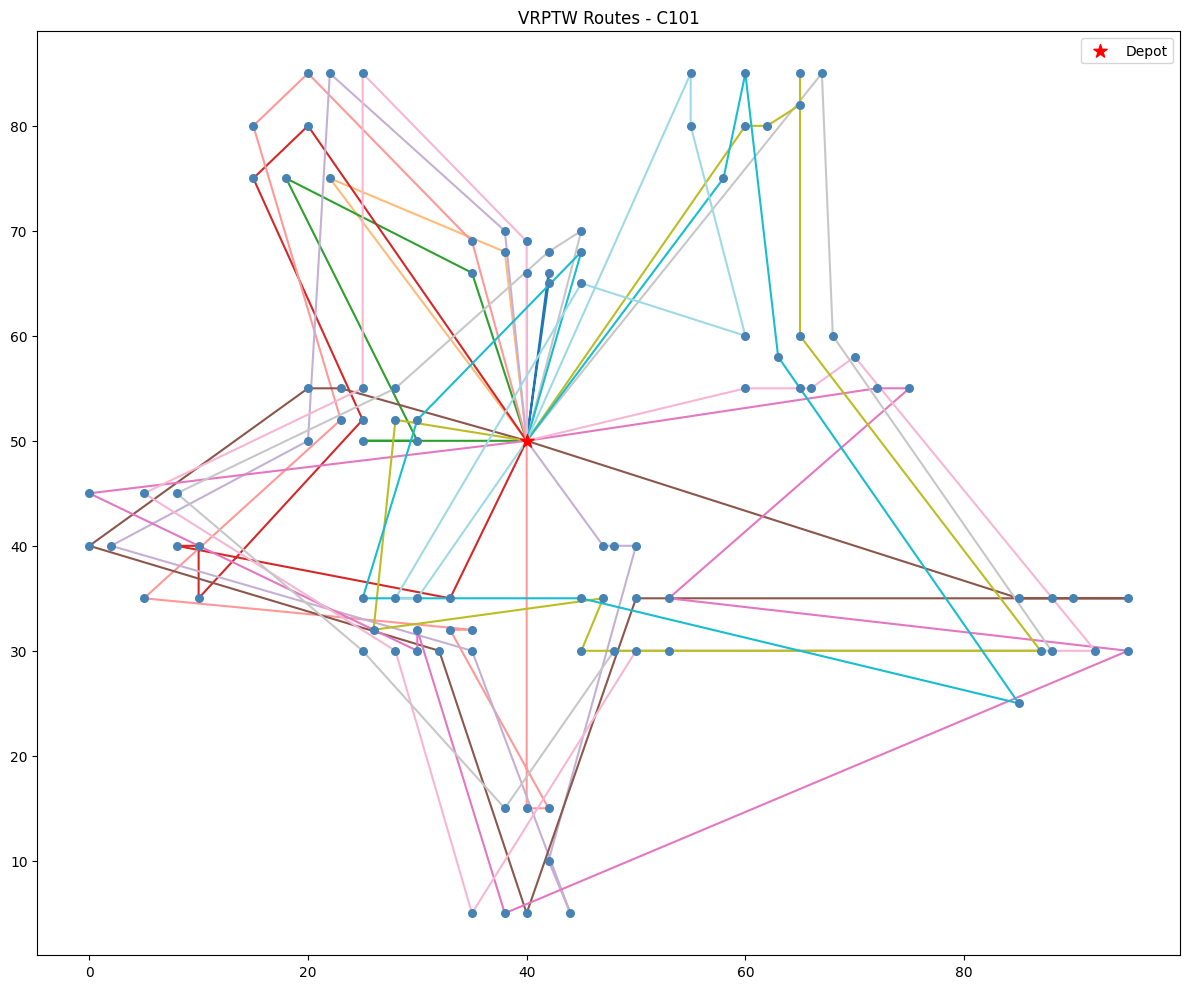

In [11]:
routes = solve(routing, manager, customers)
visualize_routes(depot, customers, routes)